# ![Machine Learning Lab](banner.jpg)

# Laboratorio 10 - Actividad

## Instrucciones generales

1. Esta actividad debe ser entregada antes de la fecha limite y es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Carga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab10.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. **Manejo y preparación de datos biológicos**: Desarrollar habilidades para explorar, limpiar y estructurar secuencias de ADN para modelos de deep learning.

2. **Implementación de modelos secuenciales**: Aplicar redes neuronales recurrentes (LSTM y GRU) para predecir el siguiente nucleótido en una secuencia de ADN, comprendiendo sus arquitecturas y diferencias.

3. **Evaluación y análisis de modelos predictivos**: Evaluar el desempeño de modelos en tareas de predicción de secuencias y analizar cómo varía la precisión en función de la longitud del contexto.

---

## Contexto

En esta actividad trabajaremos con el dataset **DNA Sequence Prediction**, que contiene secuencias de nucleótidos de genes humanos obtenidas de la base de datos NCBI Gene Database. Cada secuencia está compuesta por los 4 nucleótidos del ADN: **Adenina (A)**, **Timina (T)**, **Citosina (C)** y **Guanina (G)**.

La tarea consiste en predecir el **siguiente nucleótido** dada una ventana de contexto de nucleótidos previos.

Dataset: [DNA Sequence Prediction](https://www.kaggle.com/datasets/harshvardhan21/dna-sequence-prediction)



---

## Instrucciones

### 1. Descarga de datos y preprocesamiento (5%)

1. Descargue el dataset, explore su estructura: identifique las columnas disponibles, tipos de genes y distribución de longitudes de secuencias.
2. Limpie las secuencias: remueva los delimitadores `<>`, convierta a mayúsculas y filtre solo caracteres válidos (A, T, C, G).
3. Considere que el dataset contiene secuencias de hasta 1000 nucleótidos. Para esta actividad se recomienda trabajar con secuencias de **longitud moderada** (por ejemplo, ≤ 200 nucleótidos). Si lo considera necesario, puede trabajar con un subconjunto del conjunto de datos original que determine adecuado dependiendo de las capacidades de su Hardware.
5. Cree **ventanas deslizantes** de tamaño $k = 20$: para cada posición en una secuencia, la entrada es la subsecuencia de longitud $k$ y el target es el nucleótido siguiente.
6. Puede utilizar las particiones proporcionadas por el dataset (train/validation/test), o crearlas a partir de train.

---

### 2. Modelos a implementar (30%)

Desarrolle dos modelos de deep learning para predecir el siguiente nucleótido:

1. **Modelo LSTM**: Implemente una red que haga uso de al menos **dos capas LSTM**.
2. **Modelo GRU**: Implemente una red que haga uso de al menos **dos capas GRU**.

---

### 3. Entrenamiento y Evaluación (35%)

1. Entrene cada uno de los modelos por el numero de épocas que considere necesario. Explique Por qué.
2. Muestre las **gráficas de pérdida (loss) y precisión (accuracy) por época** para entrenamiento y validación de ambos modelos.
4. ¿Cuál modelo obtuvo mejor desempeño? y ¿Como se compara con la baseline aleatoria?.

---

### 4. Análisis de la longitud de contexto (30%)

1. Tome la mejor arquitectura del punto anterior y vuelva a entrenar utilizando ventanas de contexto de **50 y 80** nucleótidos.
2. Para cada longitud de contexto:
   - Muestre las curvas de pérdida.
   - Reporte la precisión obtenida en el conjunto de test.
3. Anote y explique las diferencias en el rendimiento según la longitud de contexto. ¿Cómo afecta tener más contexto a la capacidad predictiva del modelo?

---


# **1. Descarga de datos y preprocesamiento**

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
validation_path = "../datasets/validation.csv"
train_path = "../datasets/train.csv"
test_path = "../datasets/test.csv"

In [3]:
validation_df = pd.read_csv(validation_path)
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [4]:
def explore_file(df, name):

    print(f"ANALYSIS FOR --{name}-- SET")

    print("\nAVAILABLE COLUMNS:")
    print(df.columns.tolist())

    print("\nMISSING VALUES PER COLUMN:")
    print(df.isnull().sum())

    if "GeneType" in df.columns:
        print("\nGENE TYPE DISTRIBUTION:")
        print(df["GeneType"].value_counts())
    else:
        print("\n!!WARNING¡¡: 'GeneType' COLUMN NOT FOUND")
    
    df["sequence_length"] = df["NucleotideSequence"].str.strip("<>").str.len()
    
    print("\nSEQUENCE LENGTH STATISTICS:")
    print(df["sequence_length"].describe())

    plt.figure(figsize = (10, 5))
    sns.histplot(df["sequence_length"], kde = True, bins = 50, color = "darkblue")
    plt.title(f"SEQUENCE LENGTH DISTRIBUTION --{name}--")
    plt.xlabel("NUCLEOTIDS (LENGTH)")
    plt.ylabel("FREQUENCY")
    plt.grid(axis = "y", alpha = 0.3)
    plt.show()


In [5]:
file_mapping = {
    "TRAINING" : train_df,
    "VALIDATION" : validation_df,
    "TEST" : test_df
}

ANALYSIS FOR --TRAINING-- SET

AVAILABLE COLUMNS:
['Unnamed: 0', 'NCBIGeneID', 'Symbol', 'Description', 'GeneType', 'GeneGroupMethod', 'NucleotideSequence']

MISSING VALUES PER COLUMN:
Unnamed: 0            0
NCBIGeneID            0
Symbol                0
Description           0
GeneType              0
GeneGroupMethod       0
NucleotideSequence    0
dtype: int64

GENE TYPE DISTRIBUTION:
GeneType
PSEUDO               10220
BIOLOGICAL_REGION     6925
ncRNA                 2497
snoRNA                1148
PROTEIN_CODING         524
tRNA                   488
OTHER                  366
rRNA                   277
snRNA                  145
scRNA                    3
Name: count, dtype: int64

SEQUENCE LENGTH STATISTICS:
count    22593.000000
mean       359.724871
std        260.474730
min          2.000000
25%        120.000000
50%        295.000000
75%        518.000000
max       1000.000000
Name: sequence_length, dtype: float64


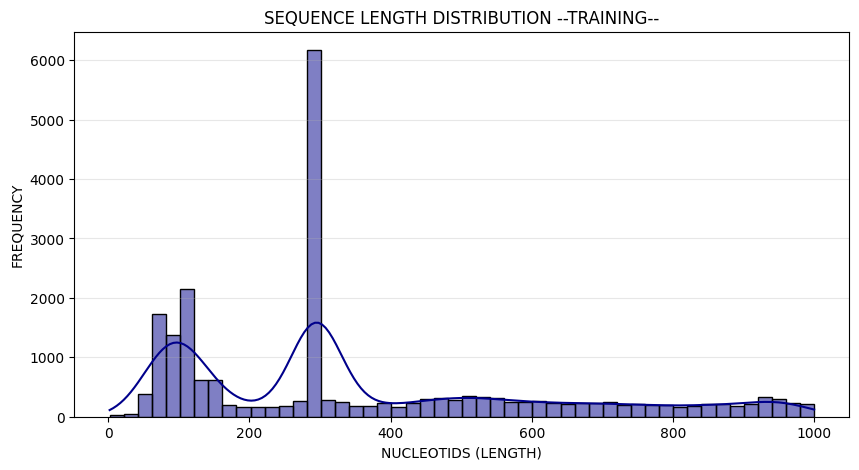

ANALYSIS FOR --VALIDATION-- SET

AVAILABLE COLUMNS:
['Unnamed: 0', 'NCBIGeneID', 'Symbol', 'Description', 'GeneType', 'GeneGroupMethod', 'NucleotideSequence']

MISSING VALUES PER COLUMN:
Unnamed: 0            0
NCBIGeneID            0
Symbol                0
Description           0
GeneType              0
GeneGroupMethod       0
NucleotideSequence    0
dtype: int64

GENE TYPE DISTRIBUTION:
GeneType
PSEUDO               2133
BIOLOGICAL_REGION    1398
ncRNA                 516
snoRNA                239
PROTEIN_CODING        101
OTHER                  88
tRNA                   72
snRNA                  22
rRNA                    8
Name: count, dtype: int64

SEQUENCE LENGTH STATISTICS:
count    4577.000000
mean      362.734979
std       259.815403
min         7.000000
25%       126.000000
50%       295.000000
75%       522.000000
max       998.000000
Name: sequence_length, dtype: float64


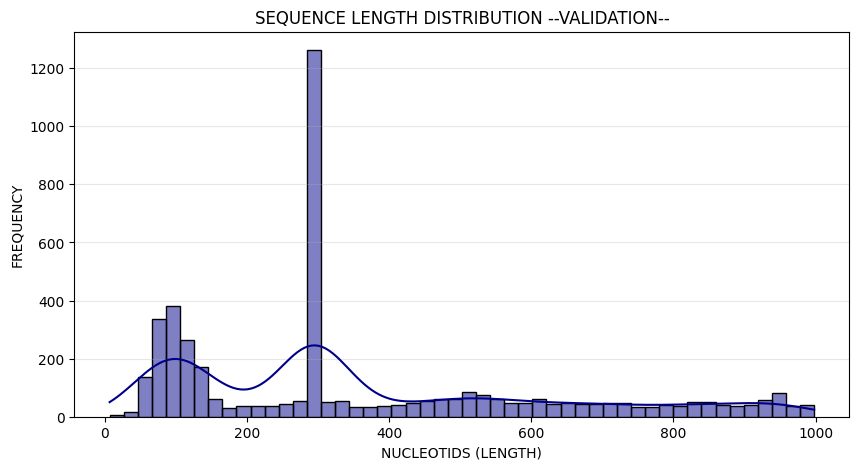

ANALYSIS FOR --TEST-- SET

AVAILABLE COLUMNS:
['Unnamed: 0', 'NCBIGeneID', 'Symbol', 'Description', 'GeneType', 'GeneGroupMethod', 'NucleotideSequence']

MISSING VALUES PER COLUMN:
Unnamed: 0            0
NCBIGeneID            0
Symbol                0
Description           0
GeneType              0
GeneGroupMethod       0
NucleotideSequence    0
dtype: int64

GENE TYPE DISTRIBUTION:
GeneType
PSEUDO               3800
BIOLOGICAL_REGION    2651
ncRNA                 894
snoRNA                405
PROTEIN_CODING        184
tRNA                  148
OTHER                 133
rRNA                   72
snRNA                  38
scRNA                   1
Name: count, dtype: int64

SEQUENCE LENGTH STATISTICS:
count    8326.000000
mean      365.491833
std       261.984806
min         4.000000
25%       128.000000
50%       295.000000
75%       524.000000
max      1000.000000
Name: sequence_length, dtype: float64


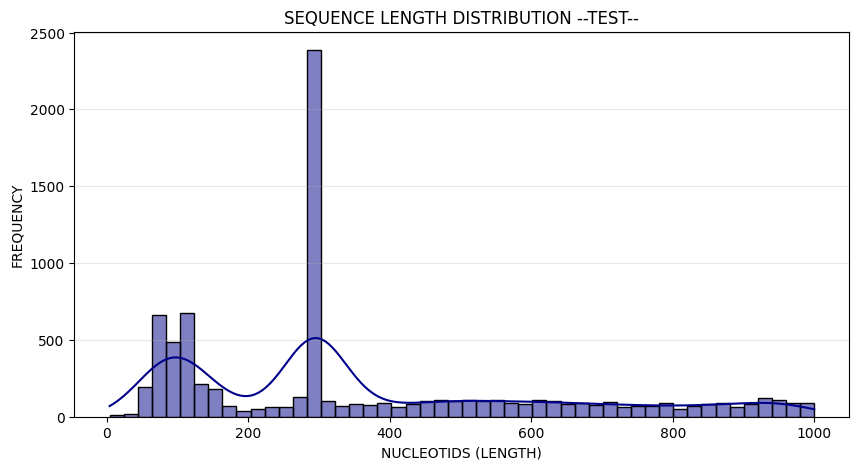

In [6]:
for label, dataframe in file_mapping.items():
    explore_file(dataframe, label)

In [7]:
def clean_genomic_sequences(df):

    df.drop(columns = ["Unnamed: 0"])
    
    temp_seqs = df["NucleotideSequence"].str.strip("<>").str.upper()
    df["CleanSequence"] = temp_seqs.str.replace(r"[^ATCG]", "", regex = True)

In [8]:
for label, dataframe in file_mapping.items():
    print(f"CLEANING --{label}--")
    clean_genomic_sequences(dataframe)

CLEANING --TRAINING--
CLEANING --VALIDATION--
CLEANING --TEST--


In [9]:
print("TRAINING SET VERIFICATION")
print(train_df.head())

TRAINING SET VERIFICATION
   Unnamed: 0  NCBIGeneID        Symbol  \
0           0   106481178      RNU4-21P   
1           1   123477792  LOC123477792   
2           2   113174975  LOC113174975   
3           3   116216107  LOC116216107   
4           4       28502      IGHD2-21   

                                         Description           GeneType  \
0               RNA, U4 small nuclear 21, pseudogene             PSEUDO   
1                Sharpr-MPRA regulatory region 12926  BIOLOGICAL_REGION   
2                 Sharpr-MPRA regulatory region 7591  BIOLOGICAL_REGION   
3  CRISPRi-validated cis-regulatory element chr10...  BIOLOGICAL_REGION   
4                immunoglobulin heavy diversity 2-21              OTHER   

  GeneGroupMethod                                 NucleotideSequence  \
0   NCBI Ortholog  <AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAG...   
1   NCBI Ortholog  <CTGGAGCGGCCACGATGTGAACTGTCACCGGCCACTGCTGCTCCG...   
2   NCBI Ortholog  <TTCCCAATTTTTCCTCTGCTTTTTAATT

In [10]:
def create_sliding_windows(df, k = 20):

    valid_df = df[df["CleanSequence"].str.len() > k].copy()
    print(f"TOTAL SEQUENCES FOR WINDOWING: {len(valid_df)}")

    X = []
    y = []

    for seq in valid_df["CleanSequence"]:

        for i in range(len(seq) - k):
            window = seq[i : i + k]
            target = seq[i + k]
            
            X.append(window)
            y.append(target)
    
    return X, y

In [11]:
windowed_data = {}

In [12]:
for label, dataframe in file_mapping.items():
    print(f"WINDOWING --{label}--")
    X, y = create_sliding_windows(dataframe)
    windowed_data[label] = (X, y)

WINDOWING --TRAINING--
TOTAL SEQUENCES FOR WINDOWING: 22568
WINDOWING --VALIDATION--
TOTAL SEQUENCES FOR WINDOWING: 4571
WINDOWING --TEST--
TOTAL SEQUENCES FOR WINDOWING: 8319


In [13]:
X_train, y_train = windowed_data["TRAINING"]
X_val, y_val     = windowed_data["VALIDATION"]
X_test, y_test   = windowed_data["TEST"]

In [ ]:
print("TRAINING SET VERIFICATION")

first_seq = file_mapping["TRAINING"]["CleanSequence"].iloc[0]
print(f"ORIGINAL SEQUENCE (FIRST 30 BP): {first_seq[:30]}")

print("\nFIRST 3 WINDOWS AND THEIR TARGETS:")
for i in range(3):
    print(f"Window {i} (X_{i}): {X_train[i]} --> Next Nucleotide (y_{i}): {y_train[i]}")

TRAINING SET VERIFICATION
ORIGINAL SEQUENCE (FIRST 30 BP): AGCTTAGCACAGTGGCAGTATCATAGGCAG

FIRST 3 WINDOWS AND THEIR TARGETS:
Window 0 (X_0): AGCTTAGCACAGTGGCAGTA --> Next Nucleotide (y_0): T
Window 1 (X_1): GCTTAGCACAGTGGCAGTAT --> Next Nucleotide (y_1): C
Window 2 (X_2): CTTAGCACAGTGGCAGTATC --> Next Nucleotide (y_2): A
